# LSTM Crypto Price Prediction — Data Analysis & Model Results

**Objective:** End-to-end walkthrough of the fixed LSTM pipeline:
1. Raw data exploration & visualisation
2. Feature engineering (5 stationary features via `preprocess.py`)
3. Train / val / test split & StandardScaler verification
4. Model architecture summary
5. Training metric comparison (BTC vs DOGE)
6. 7-day MIMO forecast visualisation

**Coins:** Bitcoin (BTC), Dogecoin (DOGE)  
**Bugs fixed:** data leakage · non-stationary target · autoregressive error compounding

## 0 · Setup

In [1]:
import sys, os, json, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch

# ── Add src/ml to path so we can import project modules ───────────────────────
REPO = Path("../").resolve()
ML_DIR = REPO / "src" / "ml"
DATA_DIR = REPO / "data" / "sample"
MODEL_DIR = ML_DIR / "model"

if str(ML_DIR) not in sys.path:
    sys.path.insert(0, str(ML_DIR))

from preprocess import (
    _load_csv, _build_features, _compute_rsi,
    _create_sequences, load_and_preprocess,
    SEQ_LEN, HORIZON,
)
from model import LSTMModel
from inference import _mimo_predict

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

COINS = ["bitcoin", "dogecoin"]
COLORS = {"bitcoin": "#F7931A", "dogecoin": "#C2A633"}

print(f"SEQ_LEN={SEQ_LEN}  HORIZON={HORIZON}")
print(f"ML_DIR : {ML_DIR}")
print(f"DATA_DIR: {DATA_DIR}")

SEQ_LEN=60  HORIZON=7
ML_DIR : /Users/ducqhle/Documents/workspace/CS315.F21.CN2.AdvanceML/src/ml
DATA_DIR: /Users/ducqhle/Documents/workspace/CS315.F21.CN2.AdvanceML/data/sample


---
## 1 · Raw Data Exploration

In [2]:
# Load both coins
dfs = {coin: _load_csv(DATA_DIR / f"{coin}.csv") for coin in COINS}

for coin, df in dfs.items():
    print(f"\n── {coin.upper()} ({'rows='+str(len(df))})", df.dtypes.to_dict())
    display(df.describe().round(4))

10:04:30  INFO  Loaded 3373 rows from /Users/ducqhle/Documents/workspace/CS315.F21.CN2.AdvanceML/data/sample/bitcoin.csv


10:04:30  INFO  Loaded 3373 rows from /Users/ducqhle/Documents/workspace/CS315.F21.CN2.AdvanceML/data/sample/dogecoin.csv



── BITCOIN (rows=3373) {'close': dtype('float64'), 'total_volume': dtype('float64')}


,close,total_volume
count,3373.0000,3.373000e+03
mean,16010.0581,1.724184e+10
std,17194.0747,1.883256e+10
min,172.1479,1.823845e+07
25%,1280.9860,1.454057e+09
50%,8881.3917,1.237354e+10
75%,26848.2399,2.743276e+10
max,73097.7670,1.788941e+11



── DOGECOIN (rows=3373) {'close': dtype('float64'), 'total_volume': dtype('float64')}


,close,total_volume
count,3373.0000,3.373000e+03
mean,0.0449,6.781944e+08
std,0.0800,2.592617e+09
min,0.0001,8.554881e+03
25%,0.0005,1.480875e+06
50%,0.0029,6.473532e+07
75%,0.0697,4.272761e+08
max,0.6818,5.096065e+10


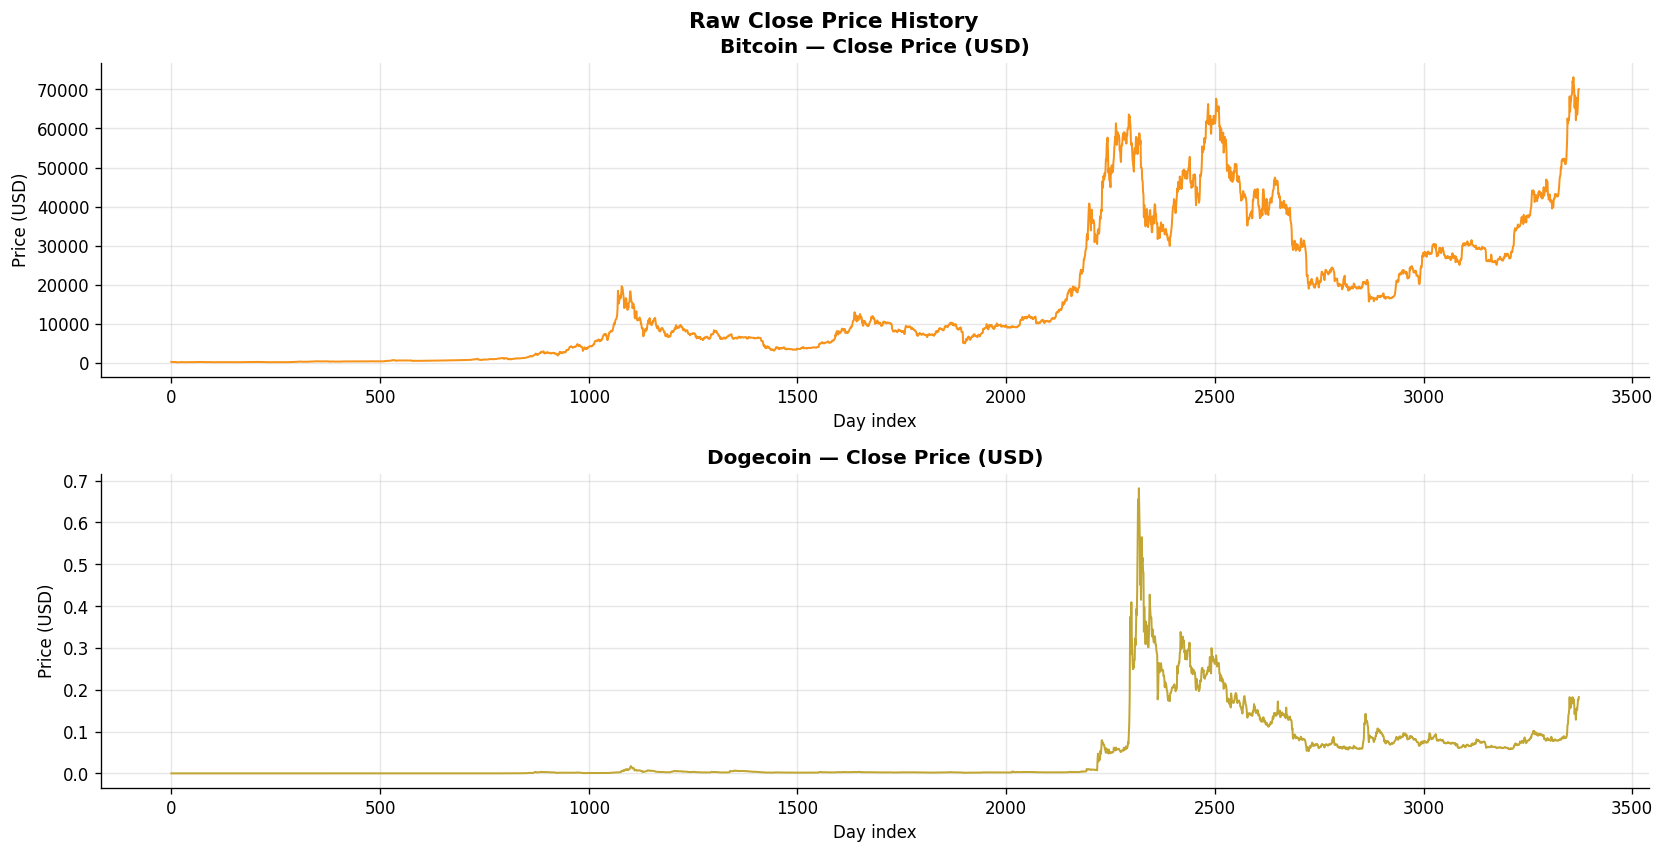

In [3]:
# ── Price history ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

for ax, coin in zip(axes, COINS):
    df = dfs[coin]
    ax.plot(df["close"].values, color=COLORS[coin], linewidth=1.2)
    ax.set_title(f"{coin.capitalize()} — Close Price (USD)", fontweight="bold")
    ax.set_xlabel("Day index")
    ax.set_ylabel("Price (USD)")

plt.tight_layout()
plt.suptitle("Raw Close Price History", y=1.01, fontsize=13, fontweight="bold")
plt.show()

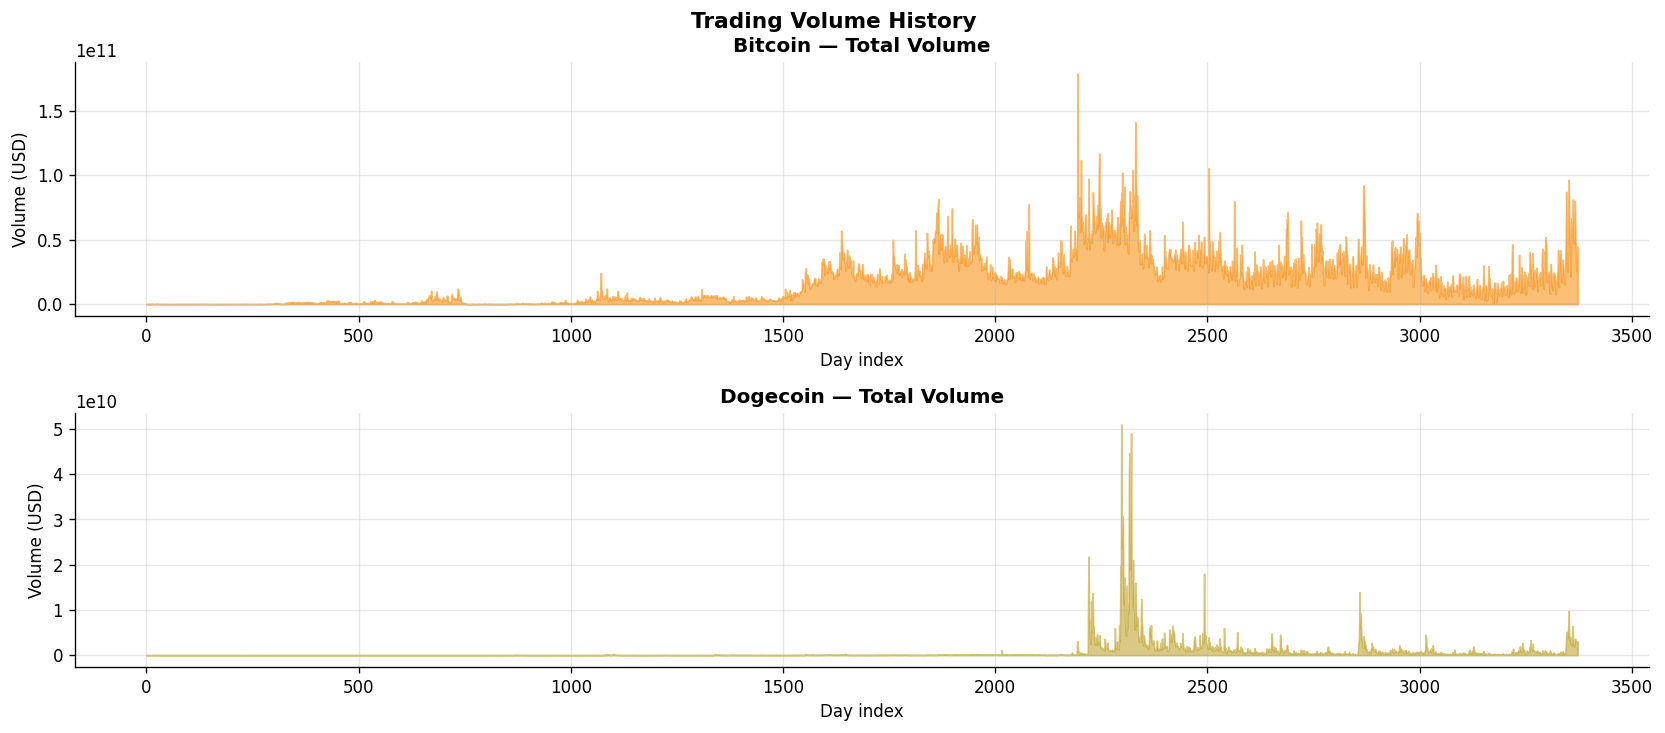

In [4]:
# ── Volume history ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

for ax, coin in zip(axes, COINS):
    df = dfs[coin]
    if "total_volume" in df.columns:
        ax.fill_between(range(len(df)), df["total_volume"].values,
                        alpha=0.6, color=COLORS[coin])
        ax.set_title(f"{coin.capitalize()} — Total Volume", fontweight="bold")
        ax.set_xlabel("Day index")
        ax.set_ylabel("Volume (USD)")
    else:
        ax.text(0.5, 0.5, "No volume column", ha="center", transform=ax.transAxes)

plt.tight_layout()
plt.suptitle("Trading Volume History", y=1.01, fontsize=13, fontweight="bold")
plt.show()

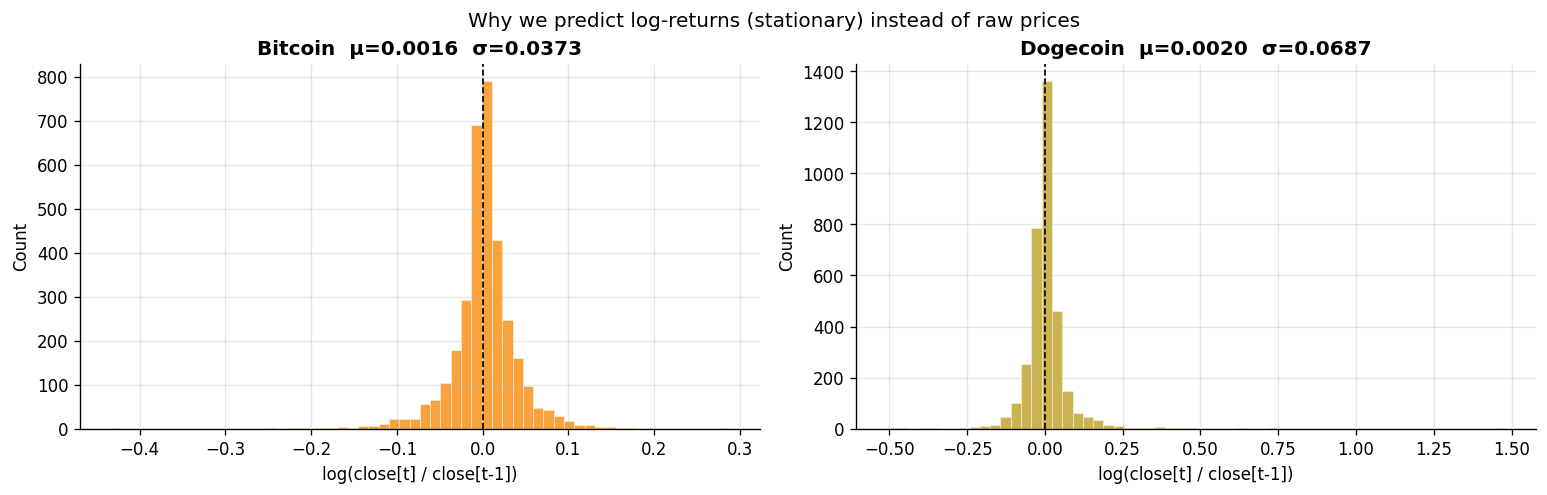

In [5]:
# ── Price return distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, coin in zip(axes, COINS):
    close = dfs[coin]["close"].values
    log_ret = np.diff(np.log(close))
    ax.hist(log_ret, bins=60, color=COLORS[coin], edgecolor="white", linewidth=0.3, alpha=0.85)
    ax.axvline(0, color="black", linewidth=1, linestyle="--")
    ax.set_title(f"{coin.capitalize()} — Daily Log-Return Distribution", fontweight="bold")
    ax.set_xlabel("log(close[t] / close[t-1])")
    ax.set_ylabel("Count")
    mu, sigma = log_ret.mean(), log_ret.std()
    ax.set_title(
        f"{coin.capitalize()}  μ={mu:.4f}  σ={sigma:.4f}",
        fontweight="bold",
    )

plt.tight_layout()
plt.suptitle("Why we predict log-returns (stationary) instead of raw prices",
             y=1.02, fontsize=12)
plt.show()

---
## 2 · Feature Engineering (Preprocessing)

We derive **5 stationary features** from the raw close price:

| # | Feature | Formula | Warmup |
|---|---------|---------|--------|
| 0 | `log_return_1d` | log(close[t]/close[t−1]) | 1 row |
| 1 | `log_return_7d` | log(close[t]/close[t−7]) | 7 rows |
| 2 | `log_return_30d` | log(close[t]/close[t−30]) | 30 rows |
| 3 | `RSI_14` | Wilder's smoothed RSI | 14 rows |
| 4 | `log_volume` | log(total_volume + 1) | 0 rows |

In [6]:
coin = "bitcoin"
df_btc = dfs[coin]
feat_raw = _build_features(df_btc)      # (N, 5) — may have NaN in warmup
valid_mask = ~np.isnan(feat_raw).any(axis=1)
feat = feat_raw[valid_mask]

print(f"Total rows: {len(feat_raw)}  →  After warmup drop: {len(feat)}")
print(f"Feature matrix shape: {feat.shape}")

feat_names = ["log_return_1d", "log_return_7d", "log_return_30d", "RSI_14", "log_volume"]
feat_df = pd.DataFrame(feat, columns=feat_names)
display(feat_df.describe().round(5))

Total rows: 3373  →  After warmup drop: 3343
Feature matrix shape: (3343, 5)


,log_return_1d,log_return_7d,log_return_30d,RSI_14,log_volume
count,3343.00000,3343.00000,3343.00000,3343.00000,3343.00000
mean,0.00173,0.01176,0.05018,53.90089,22.41893
std,0.03667,0.09848,0.21993,14.24378,2.07217
min,-0.43371,-0.56390,-0.91101,10.47749,16.71904
25%,-0.01187,-0.03426,-0.07969,43.80915,21.14486
50%,0.00170,0.00954,0.04011,52.93763,23.26623
75%,0.01705,0.06108,0.18623,63.15923,24.04206
max,0.28710,0.57489,1.07855,94.14480,25.91006


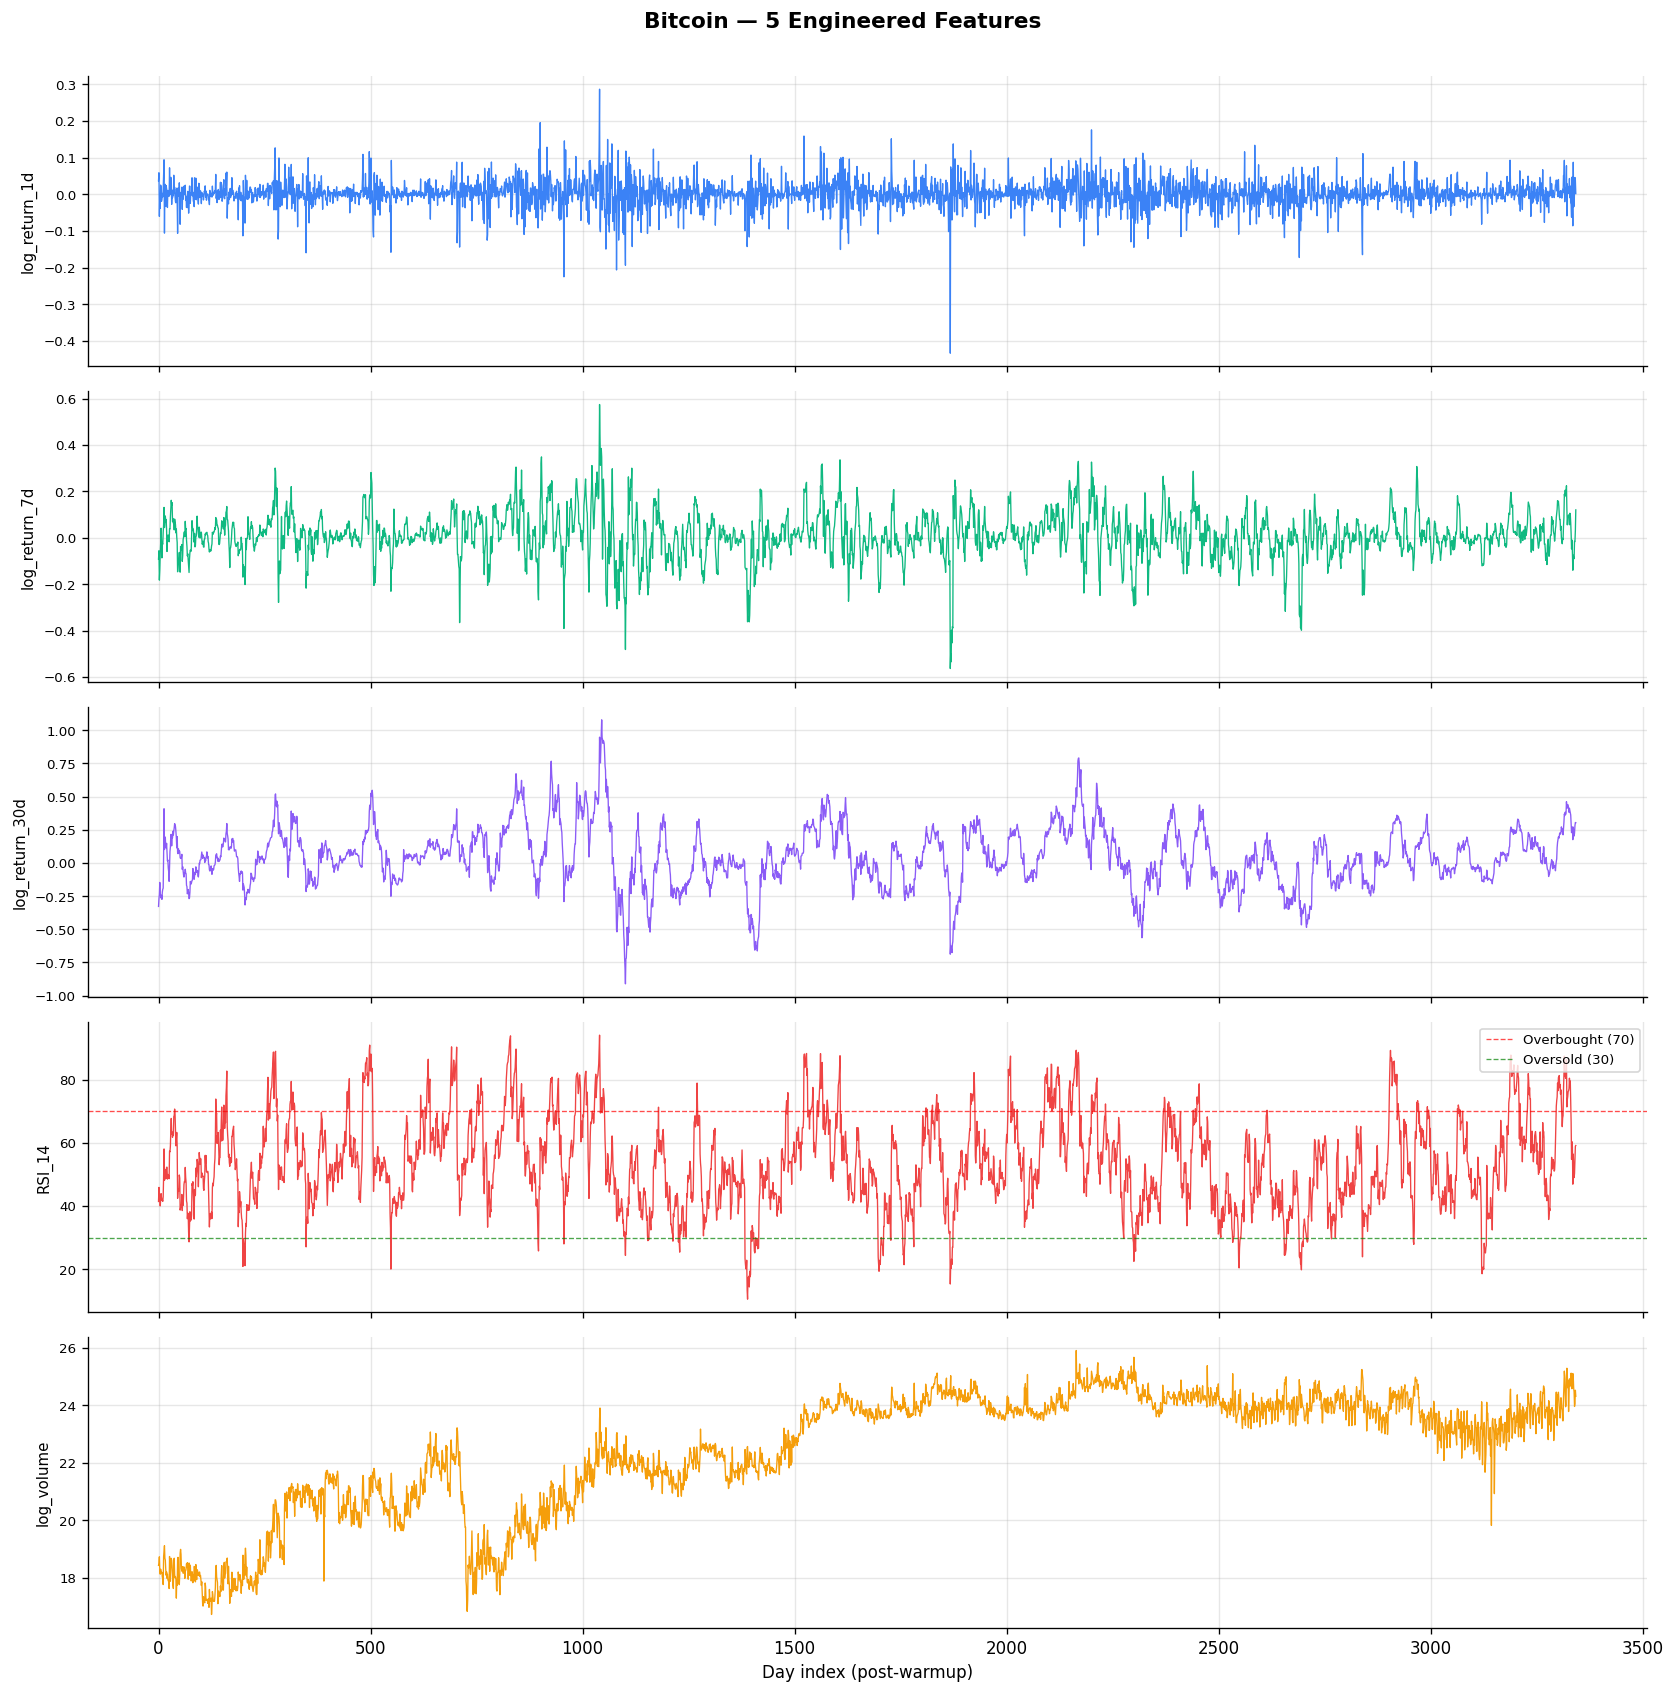

In [7]:
# ── Feature panel plot ────────────────────────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)

feat_colors = ["#3B82F6", "#10B981", "#8B5CF6", "#EF4444", "#F59E0B"]

for ax, name, color in zip(axes, feat_names, feat_colors):
    ax.plot(feat_df[name].values, color=color, linewidth=0.8)
    ax.set_ylabel(name, fontsize=9)
    ax.tick_params(axis="y", labelsize=8)

axes[3].axhline(70, color="red",   linestyle="--", linewidth=0.8, alpha=0.7, label="Overbought (70)")
axes[3].axhline(30, color="green", linestyle="--", linewidth=0.8, alpha=0.7, label="Oversold (30)")
axes[3].legend(fontsize=8, loc="upper right")

axes[-1].set_xlabel("Day index (post-warmup)")
fig.suptitle("Bitcoin — 5 Engineered Features", fontsize=13, fontweight="bold", y=1.005)
plt.tight_layout()
plt.show()

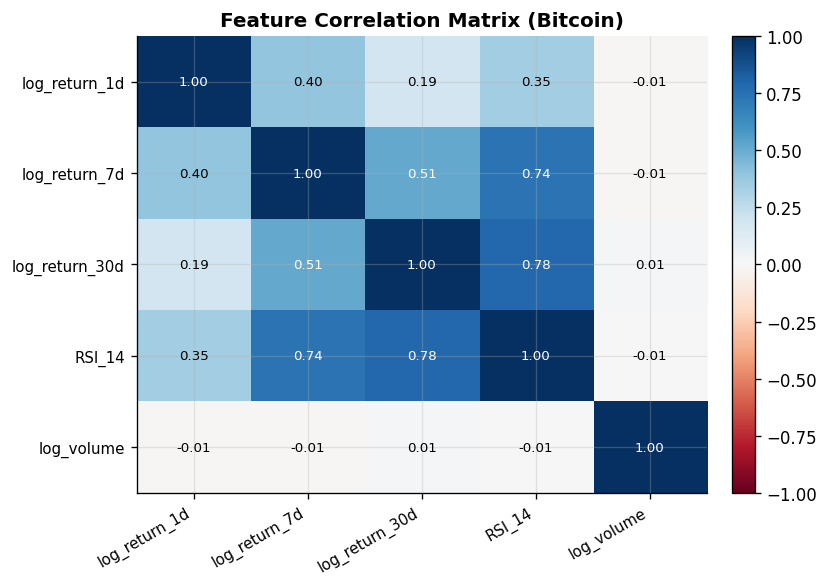

In [8]:
# ── Feature correlation heatmap ───────────────────────────────────────────────
import matplotlib.colors as mcolors

corr = feat_df.corr()
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr.values, cmap="RdBu", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ticks = range(len(feat_names))
ax.set_xticks(ticks); ax.set_xticklabels(feat_names, rotation=30, ha="right", fontsize=9)
ax.set_yticks(ticks); ax.set_yticklabels(feat_names, fontsize=9)

for i in range(len(feat_names)):
    for j in range(len(feat_names)):
        val = corr.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=8, color="white" if abs(val) > 0.5 else "black")

ax.set_title("Feature Correlation Matrix (Bitcoin)", fontweight="bold")
plt.tight_layout()
plt.show()

---
## 3 · Train / Val / Test Split & Scaler

In [9]:
# Run full preprocessing pipeline (no disk save)
X_tr, y_tr, X_v, y_v, X_te, y_te, scaler, last_price = load_and_preprocess(
    csv_path=DATA_DIR / "bitcoin.csv",
    save_scaler=False,
)

print("── Split sizes ──────────────────────────────────")
print(f"  X_train : {X_tr.shape}   y_train : {y_tr.shape}")
print(f"  X_val   : {X_v.shape}    y_val   : {y_v.shape}")
print(f"  X_test  : {X_te.shape}   y_test  : {y_te.shape}")
print(f"\n── Scaler (fitted on TRAIN only) ────────────────")
print(f"  Type    : {type(scaler).__name__}")
print(f"  mean_   : {scaler.mean_.round(5)}")
print(f"  scale_  : {scaler.scale_.round(5)}")
print(f"\n── last_price_usd : ${last_price:,.2f}")

10:04:31  INFO  Loaded 3373 rows from /Users/ducqhle/Documents/workspace/CS315.F21.CN2.AdvanceML/data/sample/bitcoin.csv


10:04:31  INFO  After warmup drop: 3343 rows remain


10:04:31  INFO  Split sizes — train: 2608, val: 268, test: 269 sequences


── Split sizes ──────────────────────────────────
  X_train : (2608, 60, 5)   y_train : (2608, 7)
  X_val   : (268, 60, 5)    y_val   : (268, 7)
  X_test  : (269, 60, 5)   y_test  : (269, 7)

── Scaler (fitted on TRAIN only) ────────────────
  Type    : StandardScaler
  mean_   : [1.820000e-03 1.255000e-02 5.475000e-02 5.399982e+01 2.209123e+01]
  scale_  : [ 0.03856  0.10289  0.23077 14.18307  2.17422]

── last_price_usd : $70,082.05


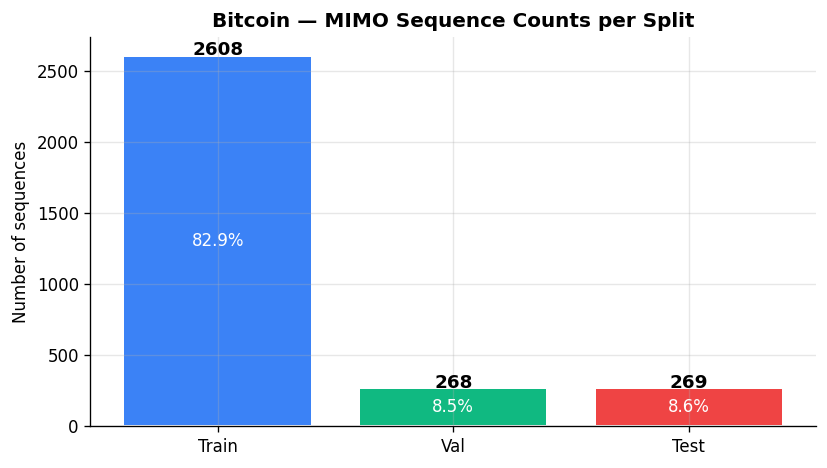

In [10]:
# ── Split size bar chart ──────────────────────────────────────────────────────
split_sizes = {"Train": len(X_tr), "Val": len(X_v), "Test": len(X_te)}
split_colors = ["#3B82F6", "#10B981", "#EF4444"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(split_sizes.keys(), split_sizes.values(),
              color=split_colors, edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, split_sizes.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            str(val), ha="center", fontsize=11, fontweight="bold")

ax.set_ylabel("Number of sequences")
ax.set_title("Bitcoin — MIMO Sequence Counts per Split", fontweight="bold")
total = sum(split_sizes.values())
for bar, (name, val) in zip(bars, split_sizes.items()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2,
            f"{val/total*100:.1f}%", ha="center", va="center",
            color="white", fontsize=10)
plt.tight_layout()
plt.show()

In [11]:
# ── Verify scaler is StandardScaler (not MinMax) ──────────────────────────────
from sklearn.preprocessing import StandardScaler

assert isinstance(scaler, StandardScaler), "BUG: should be StandardScaler!"

# Show that train feature-0 (log_return_1d) is ~N(0,1) after scaling
tr_feat0 = X_tr[:, :, 0].ravel()
print(f"Train feature-0 after StandardScaler:")
print(f"  mean  = {tr_feat0.mean():.4f}  (should be ~0)")
print(f"  std   = {tr_feat0.std():.4f}   (should be ~1)")
print(f"  min   = {tr_feat0.min():.4f}")
print(f"  max   = {tr_feat0.max():.4f}")

Train feature-0 after StandardScaler:
  mean  = 0.0028  (should be ~0)
  std   = 1.0007   (should be ~1)
  min   = -11.2946
  max   = 7.3979


---
## 4 · Model Architecture

In [12]:
model = LSTMModel(input_size=5, hidden_size=128, num_layers=2, dropout=0.2, output_size=7)

print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters   : {total_params:,}")
print(f"Trainable params   : {trainable:,}")
print(f"\nInput  shape  → (batch, {SEQ_LEN}, 5)")
print(f"Output shape  → (batch, {HORIZON})")

# Quick forward pass sanity check
dummy = torch.rand(8, SEQ_LEN, 5)
out   = model(dummy)
print(f"\nForward pass:  (8, {SEQ_LEN}, 5) → {tuple(out.shape)}  ✓")

LSTMModel(
  (lstm): LSTM(5, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=7, bias=True)
  )
)

Total parameters   : 209,927
Trainable params   : 209,927

Input  shape  → (batch, 60, 5)
Output shape  → (batch, 7)

Forward pass:  (8, 60, 5) → (8, 7)  ✓


,Layer,Type,Params
0,lstm,LSTM,201216
1,fc.0,Linear,8256
2,fc.3,Linear,455


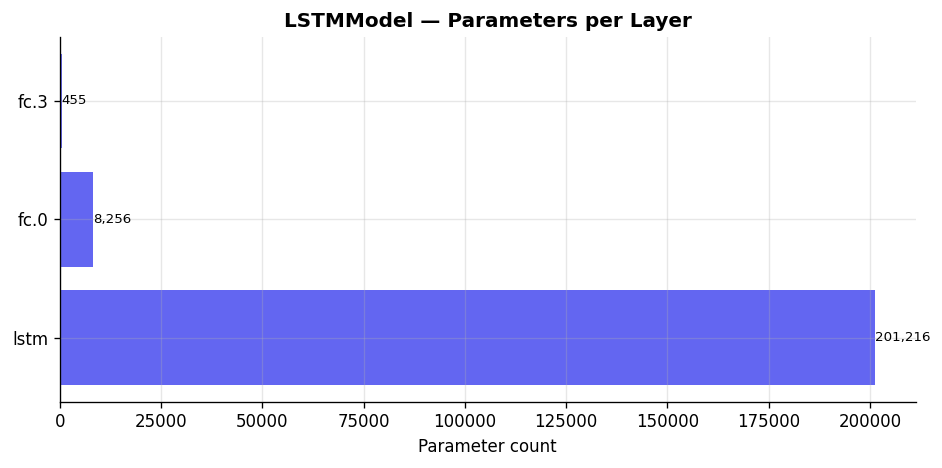

In [13]:
# ── Layer-by-layer parameter count ───────────────────────────────────────────
layer_data = []
for name, module in model.named_modules():
    params = sum(p.numel() for p in module.parameters(recurse=False))
    if params > 0:
        layer_data.append({"Layer": name, "Type": type(module).__name__, "Params": params})

layer_df = pd.DataFrame(layer_data)
display(layer_df)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(layer_df["Layer"], layer_df["Params"], color="#6366F1")
for bar, val in zip(bars, layer_df["Params"]):
    ax.text(val + 50, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", fontsize=8)
ax.set_xlabel("Parameter count")
ax.set_title("LSTMModel — Parameters per Layer", fontweight="bold")
plt.tight_layout()
plt.show()

---
## 5 · Training Metric Results

In [14]:
# Load saved metrics
metrics = {}
for coin in COINS:
    mpath = MODEL_DIR / f"metrics_{coin}.json"
    if mpath.exists():
        with open(mpath) as f:
            metrics[coin] = json.load(f)
    else:
        print(f"[WARN] {mpath} not found — run train_lstm.py first")

metrics_df = pd.DataFrame(metrics).T
display(metrics_df.round(4))

,rmse,mae,directional_accuracy_pct,epochs_trained,best_val_loss,coin,last_price_usd
bitcoin,3405.394488,2278.408631,52.788104,11,0.551331,bitcoin,70082.051225
dogecoin,0.016959,0.009787,48.327138,23,0.476465,dogecoin,0.182529


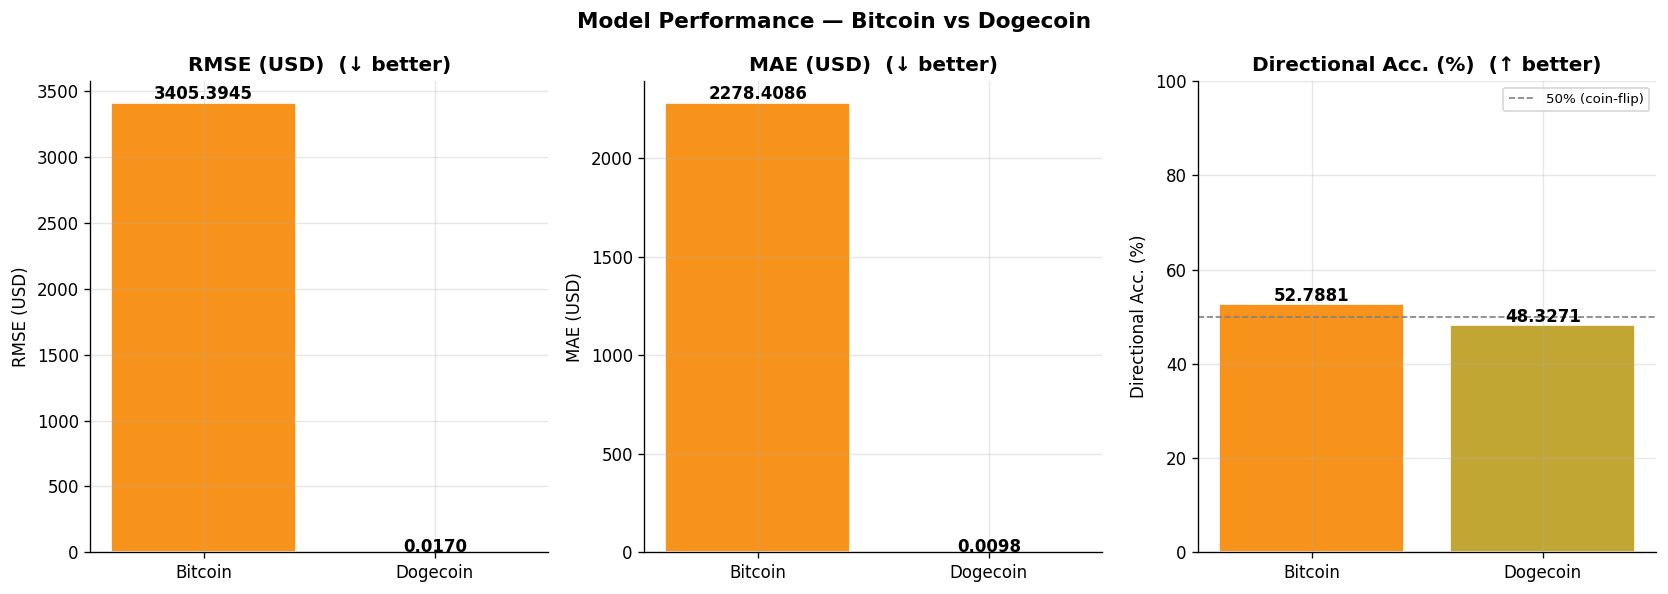


── Training Info ──────────────────────────────────────
  bitcoin     epochs= 11  best_val_loss=0.55133  last_price_usd=$70,082.0512
  dogecoin    epochs= 23  best_val_loss=0.47647  last_price_usd=$0.1825


In [15]:
# ── Metric comparison bar charts ──────────────────────────────────────────────
if metrics:
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    metric_specs = [
        ("rmse",                    "RMSE (USD)",           False),
        ("mae",                     "MAE (USD)",            False),
        ("directional_accuracy_pct","Directional Acc. (%)", True),
    ]

    for ax, (key, label, higher_better) in zip(axes, metric_specs):
        vals  = [metrics[c].get(key, 0) for c in COINS if c in metrics]
        names = [c.capitalize() for c in COINS if c in metrics]
        colors = [COLORS[c] for c in COINS if c in metrics]
        bars = ax.bar(names, vals, color=colors, edgecolor="white", linewidth=1)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                    f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")
        if key == "directional_accuracy_pct":
            ax.axhline(50, color="gray", linestyle="--", linewidth=1, label="50% (coin-flip)")
            ax.legend(fontsize=8)
            ax.set_ylim(0, 100)
        ax.set_ylabel(label)
        arrow = "↑ better" if higher_better else "↓ better"
        ax.set_title(f"{label}  ({arrow})", fontweight="bold")

    plt.suptitle("Model Performance — Bitcoin vs Dogecoin", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Training info table
    print("\n── Training Info ──────────────────────────────────────")
    for coin, m in metrics.items():
        print(f"  {coin:10s}  epochs={m.get('epochs_trained','?'):3}  "
              f"best_val_loss={m.get('best_val_loss', 0):.5f}  "
              f"last_price_usd=${m.get('last_price_usd', 0):,.4f}")

---
## 6 · 7-Day MIMO Forecast Visualisation

Load the trained model + scaler, run a single forward pass, reconstruct USD prices.

In [16]:
def load_model_and_scaler(coin: str):
    model_path  = MODEL_DIR / f"lstm_{coin}_v1.pt"
    scaler_path = MODEL_DIR / f"scaler_{coin}.pkl"
    if not model_path.exists():
        print(f"[SKIP] {model_path} not found")
        return None, None
    if not scaler_path.exists():
        print(f"[SKIP] {scaler_path} not found")
        return None, None
    m = LSTMModel(input_size=5, hidden_size=128, num_layers=2, dropout=0.2, output_size=7)
    m.load_state_dict(torch.load(model_path, map_location="cpu"))
    m.eval()
    with open(scaler_path, "rb") as f:
        sc = pickle.load(f)
    return m, sc

models   = {c: load_model_and_scaler(c) for c in COINS}
loaded   = [(c, m, sc) for c, (m, sc) in models.items() if m is not None]
print(f"Loaded models: {[c for c, *_ in loaded]}")

Loaded models: ['bitcoin', 'dogecoin']


In [17]:
# ── Generate predictions from the test set seed ───────────────────────────────
def get_test_seed_and_preds(coin: str, model, scaler):
    """Run load_and_preprocess, take last SEQ_LEN rows of test split as seed."""
    X_tr, y_tr, X_v, y_v, X_te, y_te, sc, last_price = load_and_preprocess(
        csv_path=DATA_DIR / f"{coin}.csv",
        save_scaler=False,
    )
    # Use the last window in the test split as the inference seed
    seed = X_te[-1]   # (SEQ_LEN, 5) — already scaled
    true_log_rets = y_te[-1]    # (7,) normalised log_returns

    # Convert true targets back to USD
    true_lr = true_log_rets * sc.scale_[0] + sc.mean_[0]
    true_usd = last_price * np.exp(np.cumsum(true_lr))

    pred_usd = _mimo_predict(model, seed, sc, last_price, horizon=HORIZON)
    return last_price, true_usd, pred_usd

results = {}
for coin, model, scaler in loaded:
    last_p, true_usd, pred_usd = get_test_seed_and_preds(coin, model, scaler)
    results[coin] = (last_p, true_usd, pred_usd)
    print(f"\n{coin.upper()} — last price: ${last_p:,.4f}")
    print(f"  True 7-day: {['${:.4f}'.format(p) for p in true_usd]}")
    print(f"  Pred 7-day: {['${:.4f}'.format(p) for p in pred_usd]}")

10:04:32  INFO  Loaded 3373 rows from /Users/ducqhle/Documents/workspace/CS315.F21.CN2.AdvanceML/data/sample/bitcoin.csv


10:04:32  INFO  After warmup drop: 3343 rows remain


10:04:32  INFO  Split sizes — train: 2608, val: 268, test: 269 sequences


10:04:32  INFO  Loaded 3373 rows from /Users/ducqhle/Documents/workspace/CS315.F21.CN2.AdvanceML/data/sample/dogecoin.csv


10:04:32  INFO  After warmup drop: 3343 rows remain


10:04:32  INFO  Split sizes — train: 2608, val: 268, test: 269 sequences



BITCOIN — last price: $70,082.0512
  True 7-day: ['$76496.1524', '$73920.9674', '$71634.6982', '$72510.8382', '$75923.0747', '$78887.2707', '$79048.6863']
  Pred 7-day: ['$70212.7031', '$70376.8672', '$70456.3906', '$70601.8516', '$70727.7500', '$70829.6719', '$71021.8281']

DOGECOIN — last price: $0.1825
  True 7-day: ['$0.2150', '$0.2211', '$0.2161', '$0.2308', '$0.2510', '$0.2487', '$0.2593']
  Pred 7-day: ['$0.1818', '$0.1812', '$0.1806', '$0.1808', '$0.1813', '$0.1819', '$0.1829']


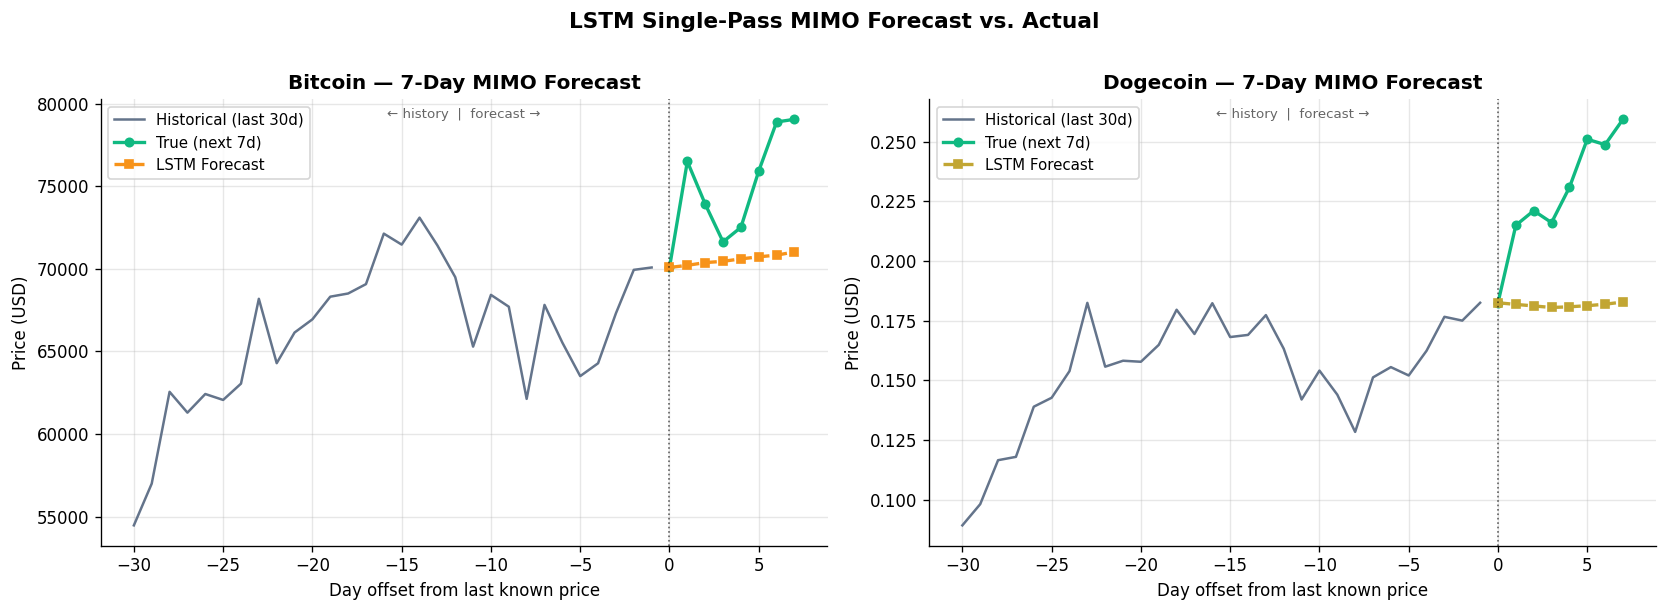

In [18]:
# ── Forecast plot: last 30 days + 7-day prediction ────────────────────────────
n_cols = max(len(results), 1)
fig, axes = plt.subplots(1, n_cols, figsize=(7 * n_cols, 5))
if n_cols == 1:
    axes = [axes]

HIST_DAYS = 30

for ax, (coin, (last_price, true_usd, pred_usd)) in zip(axes, results.items()):
    df = dfs[coin]
    hist = df["close"].values[-HIST_DAYS:]

    x_hist = np.arange(-HIST_DAYS, 0)
    x_fore = np.arange(0, HORIZON + 1)

    # Historical
    ax.plot(x_hist, hist, color="#64748B", linewidth=1.5, label="Historical (last 30d)")

    # Bridge from last historical to first forecast
    bridge_true = np.concatenate([[hist[-1]], true_usd])
    bridge_pred = np.concatenate([[hist[-1]], pred_usd])

    ax.plot(x_fore, bridge_true, color="#10B981", linewidth=2,
            marker="o", markersize=5, label="True (next 7d)")
    ax.plot(x_fore, bridge_pred, color=COLORS[coin], linewidth=2,
            marker="s", markersize=5, linestyle="--", label="LSTM Forecast")

    ax.axvline(0, color="black", linewidth=1, linestyle=":", alpha=0.6)
    ax.text(0.5, 0.98, "← history  |  forecast →",
            transform=ax.transAxes, ha="center", va="top", fontsize=8, alpha=0.6)

    ax.set_title(f"{coin.capitalize()} — 7-Day MIMO Forecast", fontweight="bold")
    ax.set_xlabel("Day offset from last known price")
    ax.set_ylabel("Price (USD)")
    ax.legend(fontsize=9)

plt.suptitle("LSTM Single-Pass MIMO Forecast vs. Actual",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


BITCOIN — Per-step error:


,Day,True USD,Pred USD,Abs Error,Rel Error %
0,1,76496.1524,70212.703125,6283.4493,8.21
1,2,73920.9674,70376.867188,3544.1002,4.79
2,3,71634.6982,70456.390625,1178.3076,1.64
3,4,72510.8382,70601.851562,1908.9866,2.63
4,5,75923.0747,70727.750000,5195.3247,6.84
5,6,78887.2707,70829.671875,8057.5989,10.21
6,7,79048.6863,71021.828125,8026.8582,10.15



DOGECOIN — Per-step error:


,Day,True USD,Pred USD,Abs Error,Rel Error %
0,1,0.2150,0.1818,0.0331,15.41
1,2,0.2211,0.1812,0.0399,18.03
2,3,0.2161,0.1806,0.0355,16.45
3,4,0.2308,0.1808,0.0500,21.65
4,5,0.2510,0.1813,0.0697,27.76
5,6,0.2487,0.1819,0.0668,26.86
6,7,0.2593,0.1829,0.0765,29.49


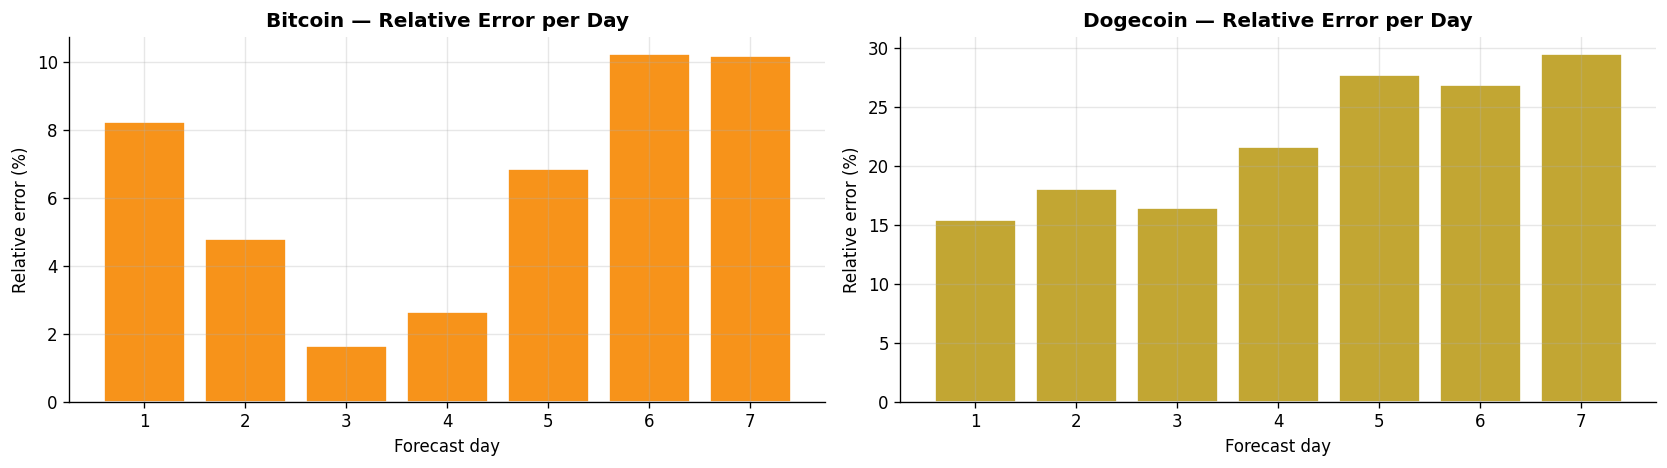

In [19]:
# ── Per-step forecast error breakdown ─────────────────────────────────────────
for coin, (last_price, true_usd, pred_usd) in results.items():
    abs_err = np.abs(true_usd - pred_usd)
    rel_err = abs_err / true_usd * 100
    print(f"\n{coin.upper()} — Per-step error:")
    err_df = pd.DataFrame({
        "Day": range(1, HORIZON + 1),
        "True USD": true_usd.round(4),
        "Pred USD": pred_usd.round(4),
        "Abs Error": abs_err.round(4),
        "Rel Error %": rel_err.round(2),
    })
    display(err_df)

if results:
    fig, axes = plt.subplots(1, len(results), figsize=(7 * len(results), 4))
    if len(results) == 1:
        axes = [axes]
    for ax, (coin, (last_price, true_usd, pred_usd)) in zip(axes, results.items()):
        rel_err = np.abs(true_usd - pred_usd) / true_usd * 100
        ax.bar(range(1, HORIZON + 1), rel_err, color=COLORS[coin], edgecolor="white")
        ax.set_xlabel("Forecast day")
        ax.set_ylabel("Relative error (%)")
        ax.set_title(f"{coin.capitalize()} — Relative Error per Day", fontweight="bold")
        ax.set_xticks(range(1, HORIZON + 1))
    plt.tight_layout()
    plt.show()

---
## 7 · Test-Set Evaluation Summary

10:04:32  INFO  Loaded 3373 rows from /Users/ducqhle/Documents/workspace/CS315.F21.CN2.AdvanceML/data/sample/bitcoin.csv


10:04:32  INFO  After warmup drop: 3343 rows remain


10:04:32  INFO  Split sizes — train: 2608, val: 268, test: 269 sequences


10:04:32  INFO  Loaded 3373 rows from /Users/ducqhle/Documents/workspace/CS315.F21.CN2.AdvanceML/data/sample/dogecoin.csv


10:04:32  INFO  After warmup drop: 3343 rows remain


10:04:32  INFO  Split sizes — train: 2608, val: 268, test: 269 sequences


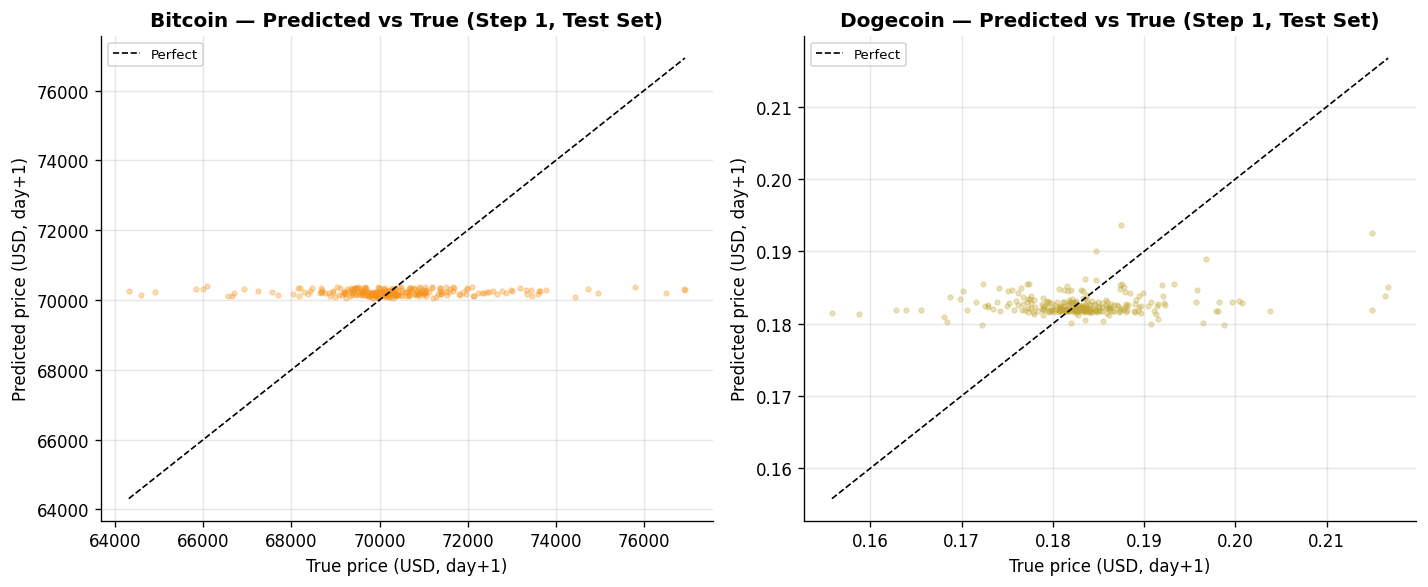

In [20]:
# ── Scatter: predicted vs true for all test sequences (step 1) ────────────────
n_cols = max(len(loaded), 1)
fig, axes = plt.subplots(1, n_cols, figsize=(6 * n_cols, 5))
if n_cols == 1:
    axes = [axes]

for ax, (coin, model, scaler) in zip(axes, loaded):
    _, _, _, _, X_te, y_te, sc, last_price = load_and_preprocess(
        csv_path=DATA_DIR / f"{coin}.csv", save_scaler=False
    )
    y_pred_norm = model.predict(X_te)          # (M, 7)

    # Un-standardise step-1
    true_lr1 = y_te[:, 0] * sc.scale_[0] + sc.mean_[0]
    pred_lr1 = y_pred_norm[:, 0] * sc.scale_[0] + sc.mean_[0]

    true_usd1 = last_price * np.exp(true_lr1)
    pred_usd1 = last_price * np.exp(pred_lr1)

    ax.scatter(true_usd1, pred_usd1, alpha=0.3, s=8, color=COLORS[coin])
    mn = min(true_usd1.min(), pred_usd1.min())
    mx = max(true_usd1.max(), pred_usd1.max())
    ax.plot([mn, mx], [mn, mx], color="black", linewidth=1, linestyle="--", label="Perfect")
    ax.set_xlabel("True price (USD, day+1)")
    ax.set_ylabel("Predicted price (USD, day+1)")
    ax.set_title(f"{coin.capitalize()} — Predicted vs True (Step 1, Test Set)",
                 fontweight="bold")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Summary

| Aspect | Fix applied |
|--------|-------------|
| **Data leakage** | `StandardScaler` fitted on train rows only; test statistics never seen during scaling |
| **Non-stationary target** | Predict 7 log-returns (mean-reverting) instead of raw price levels |
| **Error compounding** | MIMO single forward pass — no autoregressive chaining across 7 steps |

**Next steps:**
- Increase training data (CoinGecko API pull)
- Hyperparameter search (hidden size, layers, dropout)
- Add attention mechanism or Transformer backbone